Cargar librerias

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

Configuración inicial

In [27]:
archivo_csv = Path("data") / "grafo_aristas.csv"

col_origen = "node_origen"
col_destino = "node_destino"
col_frecuencia = "frecuencia_transicion"
col_probabilidad = "probabilidad_transicion"
col_costo = "costo_dijkstra"

Leer el archivo CSV

In [28]:
df = pd.read_csv(archivo_csv)

print("Archivo leído correctamente")
print(f"Número de aristas: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")
print("\nColumnas principales:")
print(df[[col_origen, col_destino, col_frecuencia, col_probabilidad]].head())

Archivo leído correctamente
Número de aristas: 24
Número de columnas: 137

Columnas principales:
  node_origen node_destino  frecuencia_transicion  probabilidad_transicion
0      HDB_20       HDB_16                     22                 0.231579
1      HDB_20       HDB_14                     18                 0.189474
2      HDB_20       HDB_19                     16                 0.168421
3      HDB_16       HDB_15                     13                 1.000000
4      HDB_20       HDB_13                     11                 0.115789


Construcción del grafo dirigido enriquecido

In [29]:
G = nx.DiGraph()

for _, row in df.iterrows():
    origen = row[col_origen]
    destino = row[col_destino]

    prob = float(row[col_probabilidad])
    freq = float(row[col_frecuencia])

    atributos = row.dropna().to_dict()

    G.add_edge(
        origen,
        destino,
        weight=prob,                         # Peso principal del grafo
        # probabilidad_transicion=prob,        # Probabilidad P(destino | origen)
        # frecuencia_transicion=freq,          # Frecuencia absoluta
        # costo_probabilistico=-np.log(prob) if prob > 0 else np.inf,
        **atributos
    )

print("\nGrafo construido:")
print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")


Grafo construido:
Nodos: 17
Aristas: 24


Asignar atributos que derivan de los nodos

In [30]:
# Frecuencia total de salida por nodo
salidas = df.groupby(col_origen)[col_frecuencia].sum().to_dict()

# Frecuencia total de entrada por nodo
entradas = df.groupby(col_destino)[col_frecuencia].sum().to_dict()

for nodo in G.nodes():
    G.nodes[nodo]["frecuencia_salida"] = salidas.get(nodo, 0)
    G.nodes[nodo]["frecuencia_entrada"] = entradas.get(nodo, 0)
    G.nodes[nodo]["frecuencia_total"] = (
        salidas.get(nodo, 0) + entradas.get(nodo, 0)
    )

Generación de la matriz de transición

In [31]:
matriz_transicion = (
    df.pivot_table(
        index=col_origen,
        columns=col_destino,
        values=col_probabilidad,
        aggfunc="sum",
        fill_value=0
    )
)

matriz_transicion.to_csv("matriz_transicion.csv")

print("\nMatriz de transición guardada como: matriz_transicion.csv")
print("\nMatriz de transición:")
print(matriz_transicion)


Matriz de transición guardada como: matriz_transicion.csv

Matriz de transición:
node_destino    HDB_10    HDB_11    HDB_13    HDB_14    HDB_15    HDB_16  \
node_origen                                                                
HDB_11        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_12        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_13        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_14        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_15        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_16        0.000000  0.000000  0.000000  0.000000  1.000000  0.000000   
HDB_17        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_18        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_19        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
HDB_20        0.084211  0.031579  0.115789  0.189474  0.010526  0.231579   
HDB_7 

Visualización del grafo dirigido enriquecido

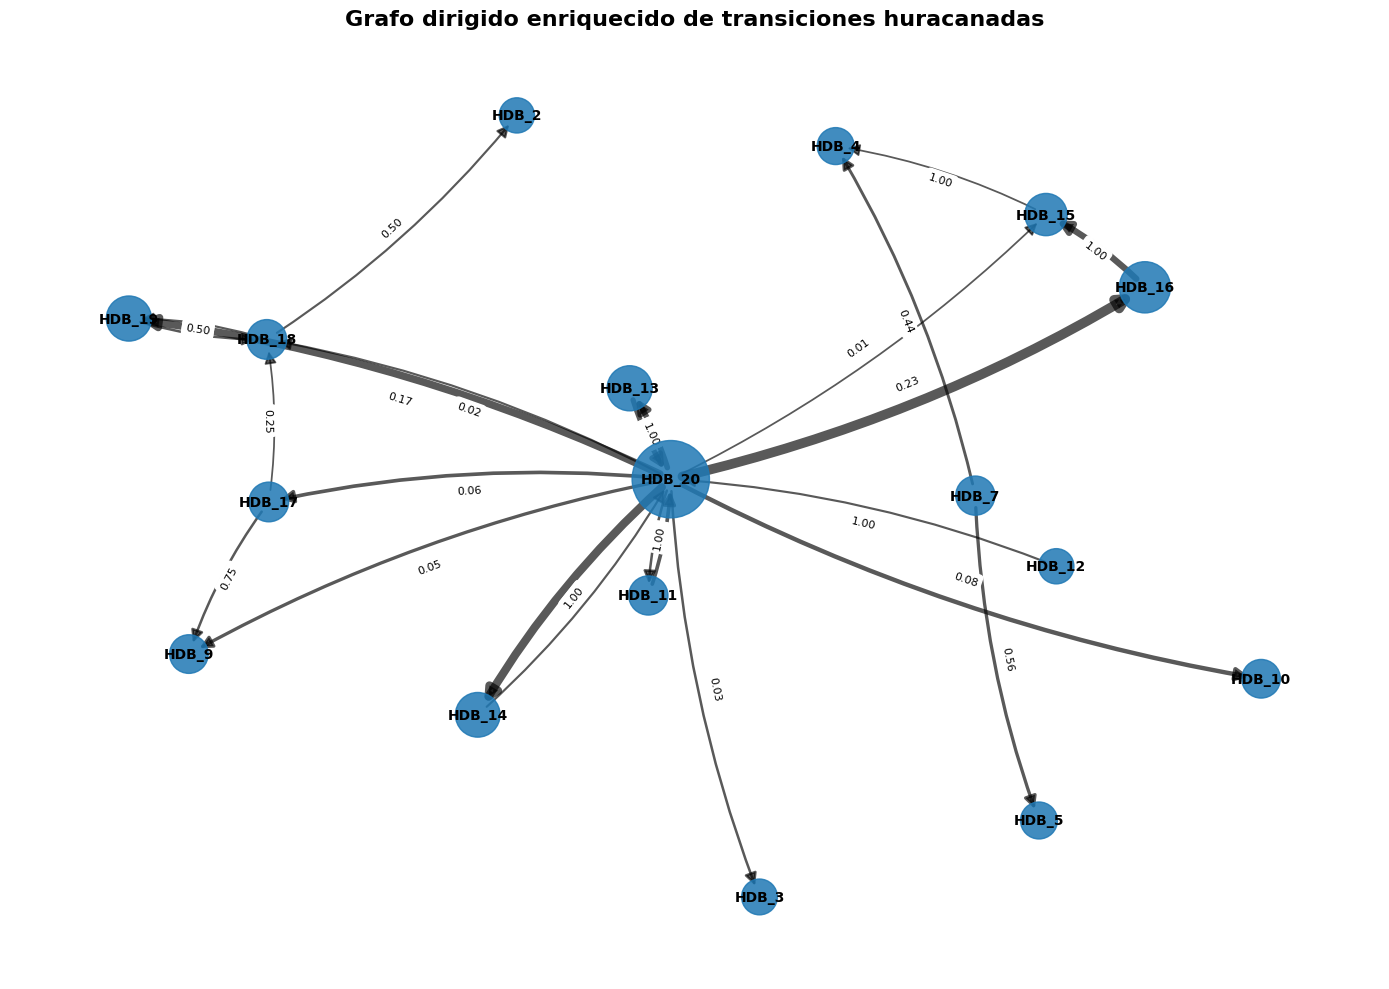


Figura guardada como: grafo_huracanes.png


In [32]:
plt.figure(figsize=(14, 10))

# Layout automático.
# Como el CSV no trae coordenadas geográficas de los nodos,
# se usa spring_layout para obtener una disposición visual.
pos = nx.spring_layout(
    G,
    seed=42,
    weight=col_frecuencia,
    k=1.2
)

# Tamaño de nodos según frecuencia total
frecuencias_nodos = nx.get_node_attributes(G, "frecuencia_total")

max_freq_nodo = max(frecuencias_nodos.values()) if frecuencias_nodos else 1

node_sizes = [
    600 + 2500 * (frecuencias_nodos.get(nodo, 0) / max_freq_nodo)
    for nodo in G.nodes()
]

# Grosor de aristas según frecuencia de transición
frecuencias_aristas = [
    G[u][v].get(col_frecuencia, 1)
    for u, v in G.edges()
]

max_freq_arista = max(frecuencias_aristas) if frecuencias_aristas else 1

edge_widths = [
    1 + 6 * (freq / max_freq_arista)
    for freq in frecuencias_aristas
]

# Dibujar nodos
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

# Dibujar aristas dirigidas
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    arrows=True,
    arrowsize=18,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.08",
    alpha=0.65
)

# Etiquetas de nodos
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

# Etiquetas de aristas con probabilidad de transición
edge_labels = {
    (u, v): f"{G[u][v].get(col_probabilidad, 0):.2f}"
    for u, v in G.edges()
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.5
)

plt.title(
    "Grafo dirigido enriquecido de transiciones huracanadas",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.savefig("grafo_huracanes.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nFigura guardada como: grafo_huracanes.png")